In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df['TotalCharges'].value_counts()
(df['TotalCharges']  == " ").sum()

np.int64(11)

# Handle missing values

In [6]:
df2 = df.copy()

In [7]:
df2["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df2["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df2.dropna(inplace=True)

In [10]:
df2["TotalCharges"].isnull().sum()

np.int64(0)

In [11]:
df2.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EDA - exploratory data analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

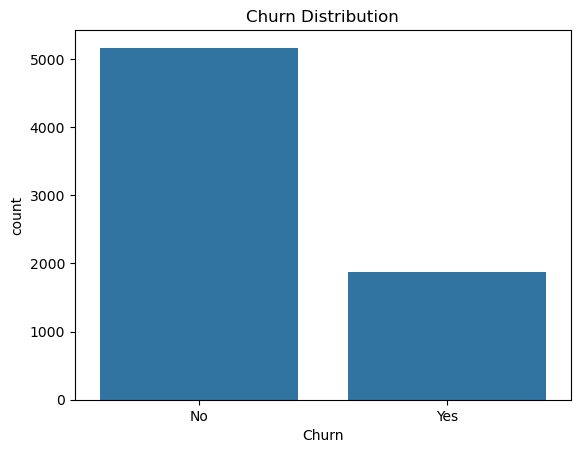

In [13]:
sns.countplot(x="Churn", data=df2)
plt.title("Churn Distribution")
plt.show()

In [14]:
classes_count = df2["Churn"].value_counts()
classes_count

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Text(0.5, 1.0, 'Is customer churn or not?')

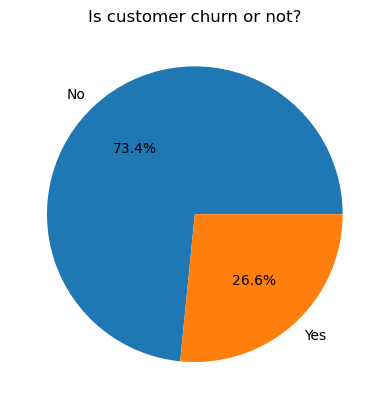

In [15]:
plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is customer churn or not?")

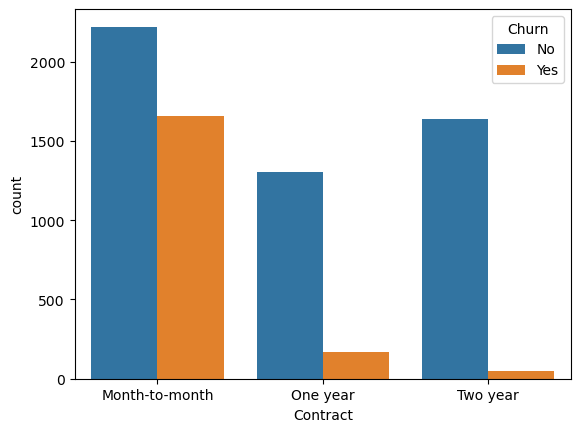

In [16]:
sns.countplot(x='Contract', hue='Churn', data=df2)
plt.show()

#### "Customers with month-to-month contracts are more likely to churn due to lack of long-term commitment."

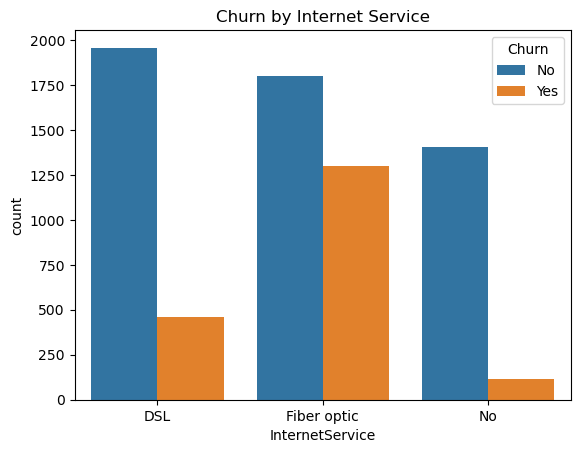

In [17]:
# Internet vs Churn

sns.countplot(x="InternetService", hue="Churn", data=df2)
plt.title("Churn by Internet Service")
plt.show()

#### "Customers using fiber optic internet show higher churn, possibly due to higher costs or unmet expectations."

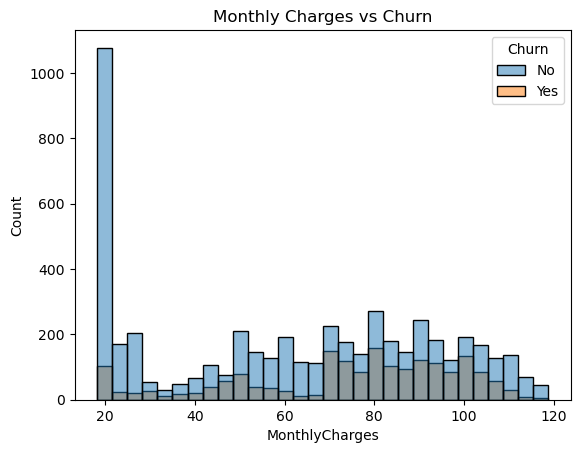

In [18]:
# MonthlyCharges vs Churn
sns.histplot(x="MonthlyCharges", hue="Churn", data=df2, bins=30)
plt.title("Monthly Charges vs Churn")
plt.show()

#### "Customers with higher monthly charges tend to churn more, indicating price sensitivity."

<Axes: xlabel='tenure', ylabel='Count'>

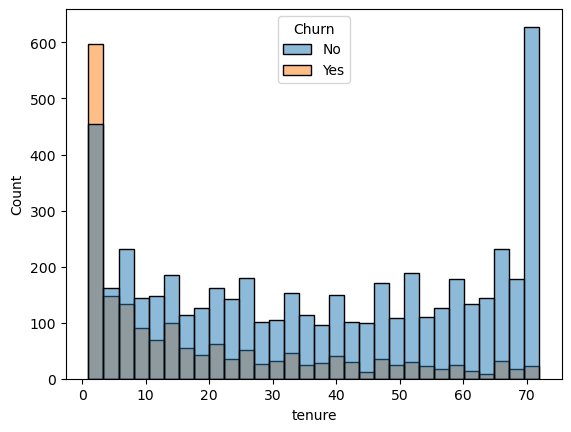

In [19]:
# Tenure vs Churn
sns.histplot(x="tenure", hue="Churn", data=df2, bins=30)

#### "Customers with lower tenure are more likely to churn, indicating the importance of early engagement."

In [20]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df2.drop("customerID", axis=1, inplace=True)

# Encoding

In [22]:
df2["Churn"] = df2["Churn"].map({"Yes":1, "No":0})

In [23]:
df2 = pd.get_dummies(df2, drop_first=True)

In [24]:
df2

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


#### "After encoding, categorical features are converted into numerical format, and boolean values are automatically interpreted as binary (0/1) by ML models."

# Train-Test-Split + Feature Scaling

In [25]:
X = df2.drop("Churn", axis=1)
y = df2["Churn"]

In [26]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [27]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_test = X_test.astype(int)
X_train = X_train.astype(int)

## Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,recall_score
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
lr_model = LogisticRegression(max_iter=10000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [65]:
y_pred = model.predict(X_test_scaled)

In [66]:
print("----Logistic Regression----")
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

----Logistic Regression----
Accuracy :  0.7277896233120114
Recall :  0.786096256684492
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



#### =>We focus on recall because We want to detect maximum churn customers.

In [67]:
# Check overfit and Underfit

y_train_pred = model.predict(X_train_scaled)
print("Training Accuracy : ", accuracy_score(y_train, y_train_pred))

y_test_pred = model.predict(X_test_scaled)
print("Test Accuracy : ", accuracy_score(y_test, y_test_pred))

Training Accuracy :  0.8106666666666666
Test Accuracy :  0.7277896233120114


## Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight="balanced")
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced')

In [69]:
y_pred = rf_model.predict(X_test_scaled)

In [70]:
print("----Random Forest---")
print("Recall : ", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

----Random Forest---
Recall :  0.4732620320855615
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



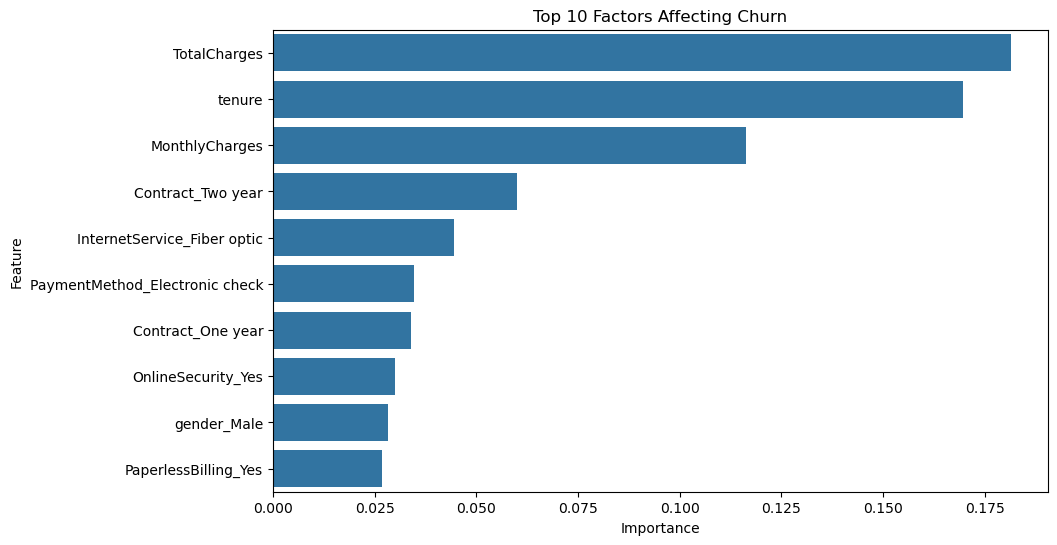

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Factors Affecting Churn')
plt.show()

## KNN

In [72]:
from sklearn.neighbors import KNeighborsClassifier

In [73]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [74]:
import warnings
warnings.filterwarnings("ignore")

In [75]:
y_pred = knn_model.predict(X_test_scaled)

In [76]:
print("---KNN---")
print("Recall : ", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

---KNN---
Recall :  0.5053475935828877
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.55      0.51      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.75      1407



## Naive Bayes


In [77]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [78]:
y_pred = nb_model.predict(X_test_scaled)

In [79]:
print("---Naive Bayes---")
print("Recall : ", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

---Naive Bayes---
Recall :  0.8689839572192514
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      1033
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1407
   macro avg       0.68      0.72      0.64      1407
weighted avg       0.79      0.66      0.68      1407



## XGBoost

In [80]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    scale_pos_weight=3,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("--- XGBoost Performance ---")
print("Recall Score:", recall_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

--- XGBoost Performance ---
Recall Score: 0.786096256684492

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



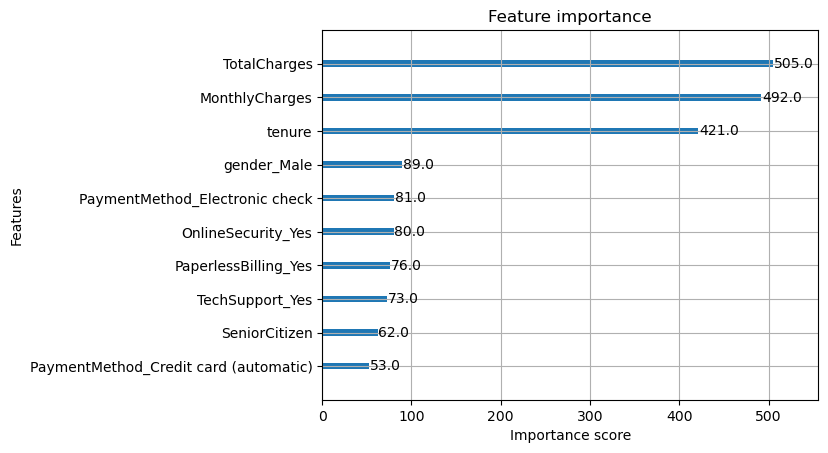

In [81]:
# Extract feature names from your DataFrame X
features = X.columns.tolist()
xgb_model.get_booster().feature_names = features
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb_model, max_num_features=10)
plt.show()

In [82]:
from sklearn.model_selection import GridSearchCV

# 1. Parameter grid define karein
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.05],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=3, random_state=42),
    param_grid=param_grid,
    cv=3, 
    scoring='recall',
)

grid_search.fit(X_train_scaled, y_train)

# 4. Best parameters dekhein
print("Best Parameters found: ", grid_search.best_params_)

Best Parameters found:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


print("---Naive Bayes---")
print("Recall : ", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

## Model Comparison

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

# 1. Sabhi models ko unique names ke saath train karna
lr_model = LogisticRegression(class_weight='balanced').fit(X_train, y_train)
rf_model = RandomForestClassifier(class_weight='balanced').fit(X_train, y_train)
knn_model = KNeighborsClassifier().fit(X_train, y_train)
nb_model = GaussianNB().fit(X_train, y_train)
xgb_model = XGBClassifier().fit(X_train, y_train)

# 2. Models ki dictionary banana
models_dict = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "K-Nearest Neighbors": knn_model,
    "Naive Bayes": nb_model,
    "XGBoost": xgb_model
}

results = []

# 3. Loop chala kar metrics calculate karna
for name, m in models_dict.items():
    y_pred = m.predict(X_test)
    
    # Correct order: (actual, predicted)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # Isse Naive Bayes ka recall 0.87 aayega
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 2),
        "Precision": round(prec, 2),
        "Recall": round(rec, 2),
        "F1-Score": round(f1, 2)
    })

# 4. Table display karna
comparison_df = pd.DataFrame(results)
print("--- Comparison Table (Final) ---")
display(comparison_df.sort_values(by="Recall", ascending=False))

--- Comparison Table (Final) ---


,Model,Accuracy,Precision,Recall,F1-Score
3,Naive Bayes,0.66,0.43,0.87,0.57
0,Logistic Regression,0.74,0.50,0.76,0.61
1,Random Forest,0.80,0.66,0.49,0.56
4,XGBoost,0.77,0.57,0.49,0.53
2,K-Nearest Neighbors,0.77,0.59,0.44,0.50


### After comparing all models, Logistic Regression is selected as the best model. While Naive Bayes achieved a higher recall (0.87), its low accuracy (0.66) makes it less reliable for business decisions. Logistic Regression provides a more balanced performance with high Accuracy and strong Recall, effectively identifying potential churners without excessive false alarms.